In [11]:
import re
import matplotlib.pyplot as plt

In [12]:
def parse_matrix_logs(file_name):
    results = []
    current_block = {}
    
    # with문을 사용하면 작업이 끝난 후 자동으로 파일을 닫아주어 안전합니다.
    with open(file_name, "r", encoding="utf-8") as f:
        # 파일 객체 f를 그대로 반복문에 넣으면 한 줄씩 끝까지 읽어옵니다.
        for line in f:
            line = line.strip()
            
            # 빈 줄이거나 구분선(====)인 경우 건너뜀
            if not line or line.startswith('==='):
                continue
                
            # 1. 헤더 라인 파싱 (Size와 Density 추출)
            header_match = re.search(r'Test Matrix Size:\s*(\d+x\d+).*?Density:\s*(\d+)%', line)
            if header_match:
                if current_block:
                    results.append(current_block)
                
                current_block = {
                    'Matrix Size': header_match.group(1),
                    'Density (%)': int(header_match.group(2))
                }
                continue
                
            # 2. 연산 데이터 라인 파싱 (연산명과 시간 추출)
            data_match = re.search(r'\[(.*?)\]\s+(\d+)\s+us', line)
            if data_match and current_block is not None:
                operation_name = data_match.group(1).strip()
                time_us = int(data_match.group(2))
                current_block[operation_name] = time_us
                
    # 마지막 블록 저장
    if current_block:
        results.append(current_block)
        
    return results

# 실행 및 결과 출력

parsed_data = parse_matrix_logs("./output.txt")

In [13]:
parsed_data

[{'Matrix Size': '10x10',
  'Density (%)': 0,
  'Dense Add': 1,
  'Sparse Add': 3,
  'Dense Sub': 0,
  'Sparse Sub': 0,
  'Dense Mul': 1,
  'Sparse Mul': 2,
  'Dense Div': 4,
  'Sparse Div': 0,
  'Dense Trans': 0,
  'Sparse Trans': 1},
 {'Matrix Size': '50x50',
  'Density (%)': 0,
  'Dense Add': 7,
  'Sparse Add': 1,
  'Dense Sub': 10,
  'Sparse Sub': 0,
  'Dense Mul': 74,
  'Sparse Mul': 0,
  'Dense Div': 12,
  'Sparse Div': 0,
  'Dense Trans': 11,
  'Sparse Trans': 0},
 {'Matrix Size': '100x100',
  'Density (%)': 0,
  'Dense Add': 22,
  'Sparse Add': 0,
  'Dense Sub': 22,
  'Sparse Sub': 0,
  'Dense Mul': 534,
  'Sparse Mul': 0,
  'Dense Div': 11,
  'Sparse Div': 0,
  'Dense Trans': 38,
  'Sparse Trans': 0},
 {'Matrix Size': '200x200',
  'Density (%)': 0,
  'Dense Add': 91,
  'Sparse Add': 1,
  'Dense Sub': 91,
  'Sparse Sub': 0,
  'Dense Mul': 3907,
  'Sparse Mul': 0,
  'Dense Div': 136,
  'Sparse Div': 0,
  'Dense Trans': 87,
  'Sparse Trans': 0},
 {'Matrix Size': '500x500',
  'Den

In [14]:
def get_data(size:str, op:str):
    result = []
    for data in parsed_data:
        if data['Matrix Size'] == size:
            result.append(data[op])
    return result


a = get_data('500x500','Dense Add')
len(parsed_data)

600

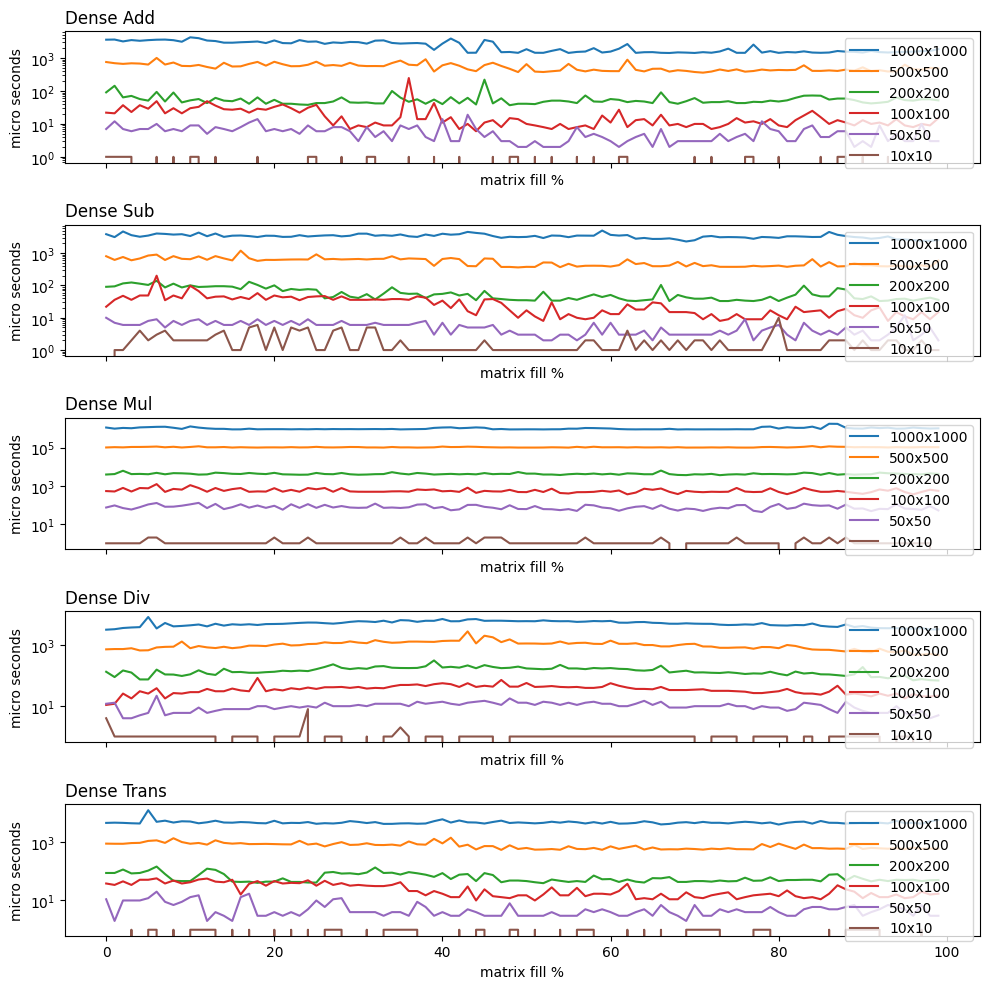

In [21]:
def show_plot(type,op,ax:plt.Axes):
    ax.plot(range(100),get_data('1000x1000',f'{type} {op}'), label="1000x1000")
    ax.plot(range(100),get_data('500x500',f'{type} {op}'), label="500x500")
    ax.plot(range(100),get_data('200x200',f'{type} {op}'), label='200x200')
    ax.plot(range(100),get_data('100x100',f'{type} {op}'), label="100x100")
    ax.plot(range(100),get_data('50x50',f'{type} {op}'), label="50x50")
    ax.plot(range(100),get_data('10x10',f'{type} {op}'), label='10x10')
    ax.set_title(f"{type} {op}", loc="left")
    ax.set_ylabel("micro seconds")
    ax.set_xlabel('matrix fill %')
    ax.legend(loc="upper right")
    ax.set_yscale('log')
    
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10,10), sharex=True)
    
show_plot('Dense','Add',axes[0])
show_plot('Dense','Sub',axes[1])
show_plot('Dense','Mul',axes[2])
show_plot('Dense','Div',axes[3])
show_plot('Dense','Trans',axes[4])

plt.tight_layout()
plt.show()


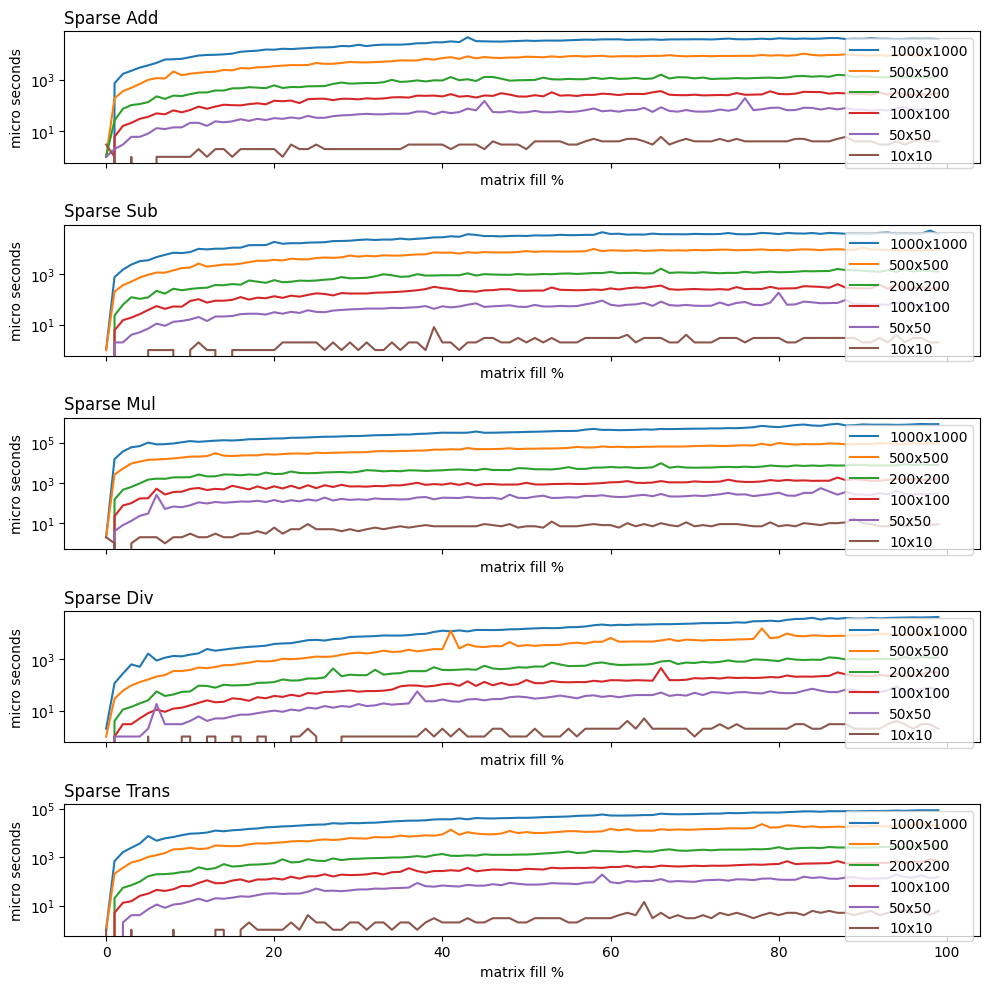

In [22]:
def show_plot(type,op,ax:plt.Axes):
    ax.plot(range(100),get_data('1000x1000',f'{type} {op}'), label="1000x1000")
    ax.plot(range(100),get_data('500x500',f'{type} {op}'), label="500x500")
    ax.plot(range(100),get_data('200x200',f'{type} {op}'), label='200x200')
    ax.plot(range(100),get_data('100x100',f'{type} {op}'), label="100x100")
    ax.plot(range(100),get_data('50x50',f'{type} {op}'), label="50x50")
    ax.plot(range(100),get_data('10x10',f'{type} {op}'), label='10x10')
    ax.set_title(f"{type} {op}", loc="left")
    ax.set_ylabel("micro seconds")
    ax.set_xlabel('matrix fill %')
    ax.legend(loc="upper right")
    ax.set_yscale('log')
    
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10,10), sharex=True)
    
show_plot('Sparse','Add',axes[0])
show_plot('Sparse','Sub',axes[1])
show_plot('Sparse','Mul',axes[2])
show_plot('Sparse','Div',axes[3])
show_plot('Sparse','Trans',axes[4])

plt.tight_layout()
plt.show()


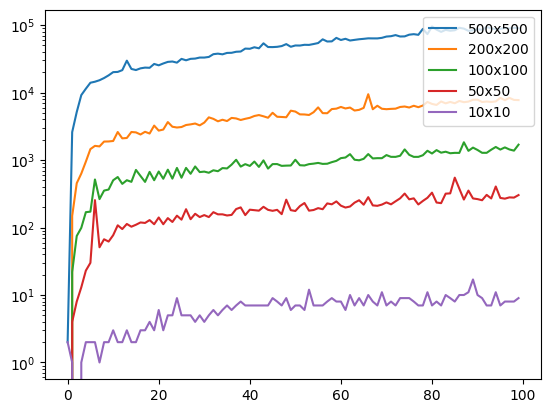

In [17]:
def show_plot():
    plt.plot(range(100),get_data('500x500','Sparse Mul'), label="500x500")
    plt.plot(range(100),get_data('200x200','Sparse Mul'), label='200x200')
    plt.plot(range(100),get_data('100x100','Sparse Mul'), label="100x100")
    plt.plot(range(100),get_data('50x50','Sparse Mul'), label="50x50")
    plt.plot(range(100),get_data('10x10','Sparse Mul'), label='10x10')
    
    plt.legend(loc="upper right")
    plt.yscale('log')
    plt.show()
    
show_plot()

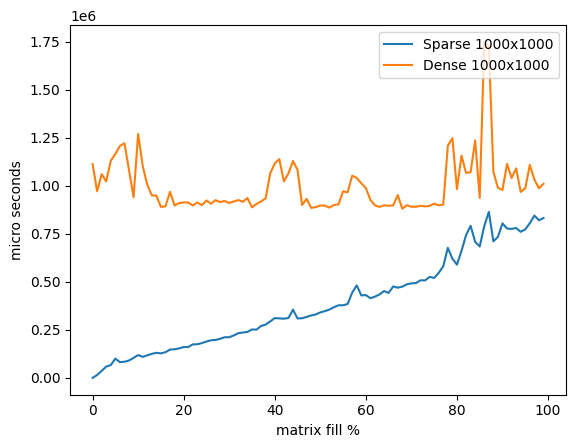

In [18]:
def show_plot():
    plt.plot(range(100),get_data('1000x1000','Sparse Mul')[:100], label="Sparse 1000x1000")
    plt.plot(range(100),get_data('1000x1000','Dense Mul')[:100], label="Dense 1000x1000")
    
    plt.ylabel("micro seconds")
    plt.xlabel("matrix fill %")
    
    plt.legend(loc="upper right")
    # plt.yscale('log')
    plt.show()
    
show_plot()

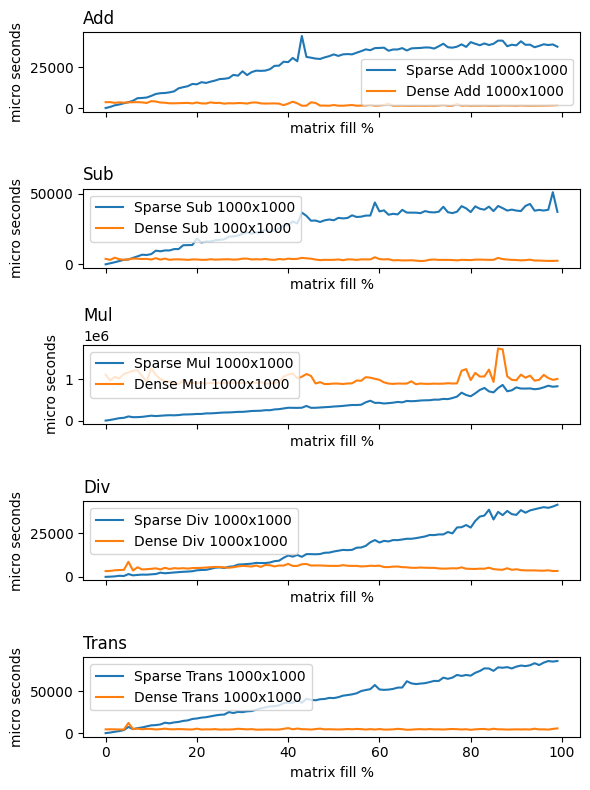

In [25]:
def sub(op,ax:plt.Axes):
    ax.plot(range(100),get_data('1000x1000',f'Sparse {op}')[:100], label=f"Sparse {op} 1000x1000")
    ax.plot(range(100),get_data('1000x1000',f'Dense {op}')[:100], label=f"Dense {op} 1000x1000")
    ax.set_title(f"{op}",loc="left")
    ax.set_ylabel("micro seconds")
    ax.set_xlabel('matrix fill %')
    ax.legend()

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(6,8), sharex=True)
    
sub('Add',axes[0])
sub('Sub',axes[1])
sub('Mul',axes[2])
sub('Div',axes[3])
sub('Trans',axes[4])

plt.tight_layout()
plt.show()
